# Task 1 - Random Forest

Dans ce notebook, nous allons implémenter un modèle de forêts aléatoires, un algorithme puissant basé sur les arbres de décision qui combine plusieurs arbres pour améliorer la précision et réduire le sur-apprentissage.

## 1. Importation des bibliothèques nécessaires

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
import warnings
warnings.filterwarnings('ignore')

# Configuration de l'affichage
%matplotlib inline

## 2. Chargement et exploration des données

Pour cette démonstration, nous utiliserons le jeu de données du cancer du sein de Wisconsin, qui est un problème de classification binaire classique.

In [2]:
# Chargement des données du cancer du sein de Wisconsin
breast_cancer = load_breast_cancer()

# Création d'un DataFrame pandas
df = pd.DataFrame(data=breast_cancer.data, columns=breast_cancer.feature_names)
df['target'] = breast_cancer.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
# Exploration des données
print("Shape of dataset:", df.shape)
print("\nInfo of dataset:")
df.info()

Shape of dataset: (569, 31)

Info of dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-n

In [4]:
# Statistiques descriptives
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


Variable cible: target

Distribution des classes:
target
1    357
0    212
Name: count, dtype: int64


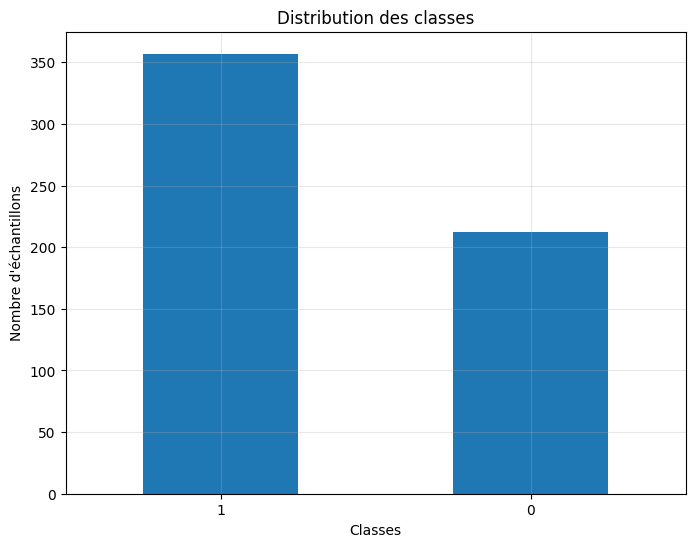

In [5]:
# Vérification de la distribution des classes (variable cible)
target_column = df.columns[-1]
print(f"Variable cible: {target_column}")
print("\nDistribution des classes:")
print(df[target_column].value_counts())

# Visualisation de la distribution des classes
plt.figure(figsize=(8, 6))
df[target_column].value_counts().plot(kind='bar')
plt.title('Distribution des classes')
plt.xlabel('Classes')
plt.ylabel('Nombre d\'échantillons')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.show()

## 3. Prétraitement des données

Séparation des caractéristiques (features) et de la variable cible.

In [6]:
# Séparation des caractéristiques (features) et de la variable cible
X = df.iloc[:, :-1]  # Toutes les colonnes sauf la dernière
y = df.iloc[:, -1]   # Dernière colonne (variable cible)

print(f"Dimensions des caractéristiques: {X.shape}")
print(f"Dimensions de la variable cible: {y.shape}")

Dimensions des caractéristiques: (569, 30)
Dimensions de la variable cible: (569,)


## 4. Division des données

Division des données en ensembles d'entraînement et de test.

In [7]:
# Division des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Taille de l'ensemble d'entraînement: {X_train.shape}")
print(f"Taille de l'ensemble de test: {X_test.shape}")

Taille de l'ensemble d'entraînement: (455, 30)
Taille de l'ensemble de test: (114, 30)


## 5. Entraînement du modèle de forêt aléatoire

Création et entraînement du modèle de forêt aléatoire avec des paramètres par défaut.

In [8]:
# Création et entraînement du modèle de forêt aléatoire
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## 6. Prédiction et évaluation du modèle

Prédiction sur l'ensemble de test et évaluation des performances du modèle.

In [9]:
# Prédiction sur l'ensemble de test
y_pred = rf_classifier.predict(X_test)
y_pred_proba = rf_classifier.predict_proba(X_test)[:, 1]  # Probabilités pour la classe positive

# Affichage des premières prédictions
results_df = pd.DataFrame({'Valeurs réelles': y_test, 'Prédictions': y_pred, 'Probabilités': y_pred_proba})
print("Comparaison des valeurs réelles et prédites:")
print(results_df.head(10))

Comparaison des valeurs réelles et prédites:
     Valeurs réelles  Prédictions  Probabilités
256                0            0          0.00
428                1            1          1.00
501                0            0          0.12
363                1            0          0.28
564                0            0          0.01
464                1            1          0.99
358                1            1          0.95
343                0            0          0.01
516                0            0          0.00
567                0            0          0.00


In [10]:
# Évaluation du modèle
accuracy = accuracy_score(y_test, y_pred)
print(f"Précision du modèle: {accuracy:.4f}")

# Rapport de classification détaillé
print("\nRapport de classification:")
print(classification_report(y_test, y_pred))

Précision du modèle: 0.9561

Rapport de classification:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



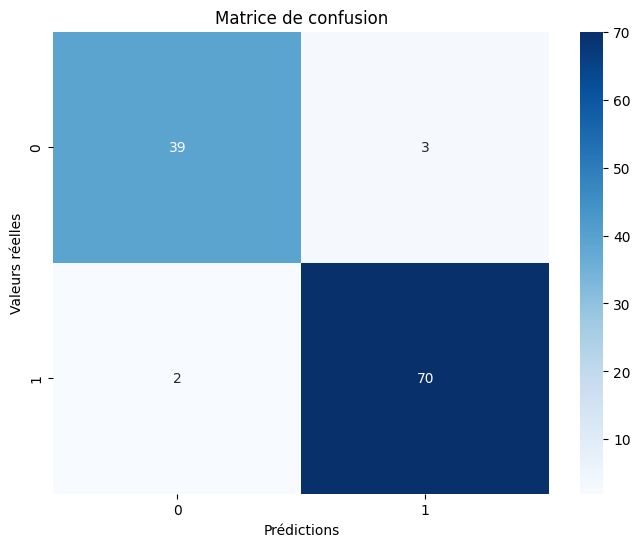

In [11]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion')
plt.xlabel('Prédictions')
plt.ylabel('Valeurs réelles')
plt.show()

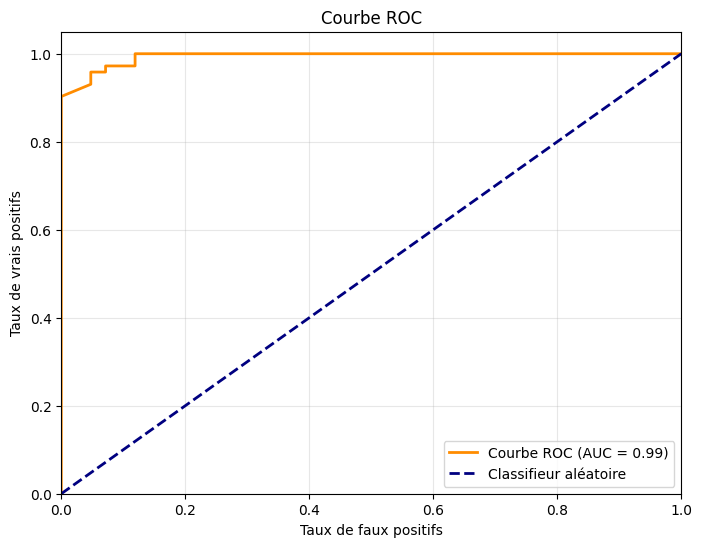

Aire sous la courbe ROC (AUC): 0.9937


In [12]:
# Courbe ROC et AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Classifieur aléatoire')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Aire sous la courbe ROC (AUC): {roc_auc:.4f}")

In [13]:
import matplotlib.animation as animation
from IPython.display import HTML

# Préparation des données pour l'animation
n_trees = range(1, 101, 2)
train_scores = []
test_scores = []

for n in n_trees:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, rf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, rf.predict(X_test)))

# Configuration de la figure
fig, ax = plt.subplots(figsize=(10, 6))
line1, = ax.plot([], [], 'b-', label='Train Accuracy')
line2, = ax.plot([], [], 'r-', label='Test Accuracy')
ax.set_xlim(0, 100)
ax.set_ylim(0.8, 1.05)
ax.set_xlabel('Nombre d\'arbres (n_estimators)')
ax.set_ylabel('Précision')
ax.set_title('Progression de la performance de la Forêt Aléatoire')
ax.legend()
ax.grid(True, alpha=0.3)

def animate(i):
    line1.set_data(list(n_trees)[:i], train_scores[:i])
    line2.set_data(list(n_trees)[:i], test_scores[:i])
    return line1, line2

ani = animation.FuncAnimation(fig, animate, frames=len(n_trees), interval=100, blit=True)
plt.close() # Empêche l'affichage de la figure statique
HTML(ani.to_jshtml())

## 7. Importance des caractéristiques

Analyse des caractéristiques les plus importantes dans la prise de décision du modèle.

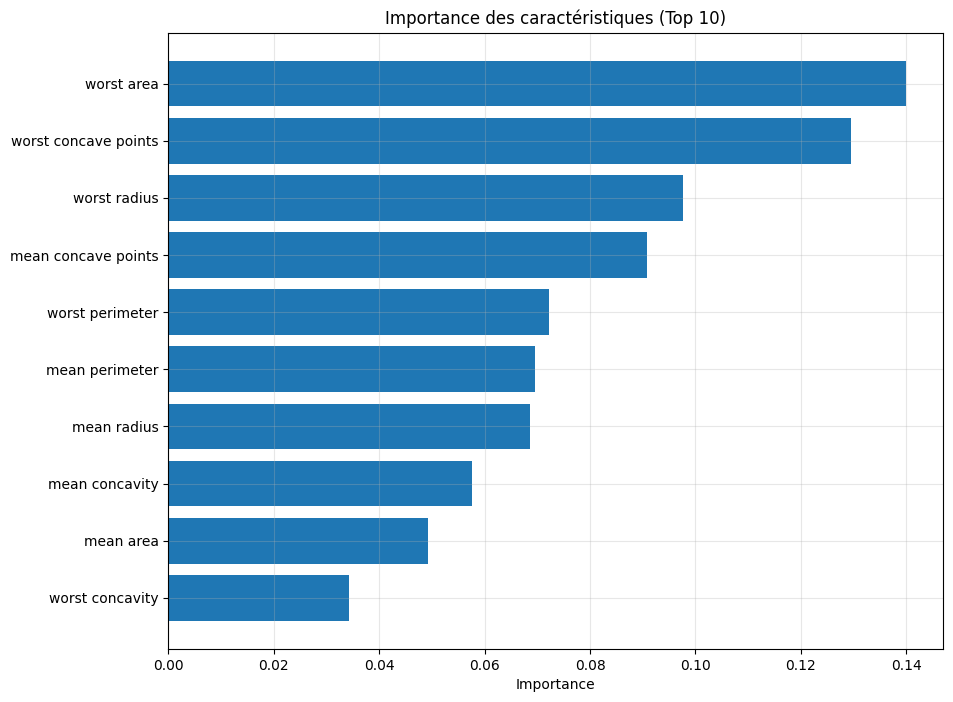

Caractéristiques les plus importantes:
                 Feature  Importance
23            worst area    0.140016
27  worst concave points    0.129530
20          worst radius    0.097696
7    mean concave points    0.090885
22       worst perimeter    0.072226
2         mean perimeter    0.069574
0            mean radius    0.068676
6         mean concavity    0.057638
3              mean area    0.049172
26       worst concavity    0.034340


In [14]:
# Importance des caractéristiques
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_classifier.feature_importances_
}).sort_values('Importance', ascending=False)

# Visualisation des 10 caractéristiques les plus importantes
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(10)
plt.barh(range(len(top_features)), top_features['Importance'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance')
plt.title('Importance des caractéristiques (Top 10)')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.show()

print("Caractéristiques les plus importantes:")
print(feature_importance.head(10))

## 8. Optimisation des hyperparamètres

Utilisation de GridSearchCV pour trouver les meilleurs hyperparamètres.

In [15]:
# Définition de la grille de paramètres
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Recherche des meilleurs paramètres
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Meilleurs paramètres trouvés:")
print(grid_search.best_params_)
print(f"\nMeilleur score de validation croisée: {grid_search.best_score_:.4f}")

Meilleurs paramètres trouvés:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Meilleur score de validation croisée: 0.9604


In [16]:
# Entraînement du modèle avec les meilleurs paramètres
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

# Évaluation du modèle optimisé
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Précision du modèle optimisé: {accuracy_best:.4f}")
print(f"Amélioration par rapport au modèle initial: {accuracy_best - accuracy:.4f}")

print("\nRapport de classification du modèle optimisé:")
print(classification_report(y_test, y_pred_best))

Précision du modèle optimisé: 0.9561
Amélioration par rapport au modèle initial: 0.0000

Rapport de classification du modèle optimisé:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## 9. Comparaison avec un arbre de décision seul

Comparaison des performances entre une forêt aléatoire et un arbre de décision seul.

In [17]:
from sklearn.tree import DecisionTreeClassifier

# Entraînement d'un arbre de décision seul
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)
y_pred_dt = dt_classifier.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)

# Scores de validation croisée
cv_scores_rf = cross_val_score(rf_classifier, X_train, y_train, cv=5)
cv_scores_dt = cross_val_score(dt_classifier, X_train, y_train, cv=5)

print(f"Précision de l'arbre de décision seul: {accuracy_dt:.4f}")
print(f"Précision de la forêt aléatoire: {accuracy:.4f}")
print(f"Différence: {accuracy - accuracy_dt:.4f}")

print(f"\nValidation croisée - Arbre de décision (moyenne): {cv_scores_dt.mean():.4f} (+/- {cv_scores_dt.std() * 2:.4f})")
print(f"Validation croisée - Forêt aléatoire (moyenne): {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std() * 2:.4f})")

Précision de l'arbre de décision seul: 0.9123
Précision de la forêt aléatoire: 0.9561
Différence: 0.0439

Validation croisée - Arbre de décision (moyenne): 0.9099 (+/- 0.0378)
Validation croisée - Forêt aléatoire (moyenne): 0.9538 (+/- 0.0469)


In [ ]:
from sklearn.decomposition import PCA

# Réduction à 2D pour la visualisation
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Grille pour dessiner les frontières
h = .02
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

fig, ax = plt.subplots(figsize=(10, 8))

def update(frame):
    ax.clear()
    n = max(1, frame * 5) # Augmente le nombre d'arbres par pallier de 5
    clf = RandomForestClassifier(n_estimators=n, random_state=42)
    clf.fit(X_train_pca, y_train)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdBu')
    ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, edgecolors='k', cmap='RdBu', alpha=0.6)
    ax.set_title(f'Frontière de décision avec {n} arbres')
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')

ani_boundary = animation.FuncAnimation(fig, update, frames=20, interval=300)
plt.close()
HTML(ani_boundary.to_jshtml())

## Conclusion

Dans ce notebook, nous avons implémenté un modèle de forêts aléatoires :
- Chargement et exploration des données du cancer du sein
- Prétraitement des données
- Division des données en ensembles d'entraînement et de test
- Entraînement du modèle de forêt aléatoire
- Évaluation du modèle avec plusieurs métriques (précision, rappel, F1-score, AUC)
- Visualisation des résultats (matrice de confusion, courbe ROC)
- Analyse de l'importance des caractéristiques
- Optimisation des hyperparamètres avec GridSearchCV
- Comparaison des performances avec un arbre de décision seul

Les forêts aléatoires sont un algorithme très puissant qui combine plusieurs arbres de décision pour améliorer la précision et réduire le sur-apprentissage. Elles fournissent également des mesures d'importance des caractéristiques utiles pour l'analyse des données.